# <span style="color:red"> Aplicaciones SIG y Ordenamiento Territorial con SIG y TICs  2023 </span>

# Trabajo práctico número 5

El objetivo de esta actividad es poner en práctica conceptos de diseño de gráficos y figuras
usando librerías de Python. El práctico cuenta con dos secciones. En la sección A se
trabajará con datos raster, mientras que en la sección B con datos no espaciales.

### Indicaciones práctico 5a


<strong>A.</strong> Desarrollar función para explorar imágenes Sentinel y generar como resultado figura
con 4 imágenes (subplots). Cada imagen debe tener su título (pueden usar cualquier
imagen Sentinel 2 del link:
https://drive.google.com/file/d/1lirEs_rjxVS2BkhwZAsS2VJU2lFRZBEL/view?usp=share
_link)
1. La primera imagen debe mostrar imagen multibanda con combinación de color real
2. La segunda imagen debe mostrar imagen multibanda con color infrarojo
3. La tercera imagen mostrando el índice NDVI
4. La cuarta imagen mostrando el índice NDWI

#### *importando librerias*

In [2]:
import rasterio as rst
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

In [3]:
warnings.filterwarnings("ignore")

#### *Leyendo datos raster*

In [4]:
sentinel2= rst.open(r"C:\Users\bruta\Documents\maletin\UACH\septimo semestre\SIG\practico 5\imagenes_sentinel\20190204T141049_20190204T142023_T19FDB.tif")

#### *figuras imagenes sentinel 2*

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


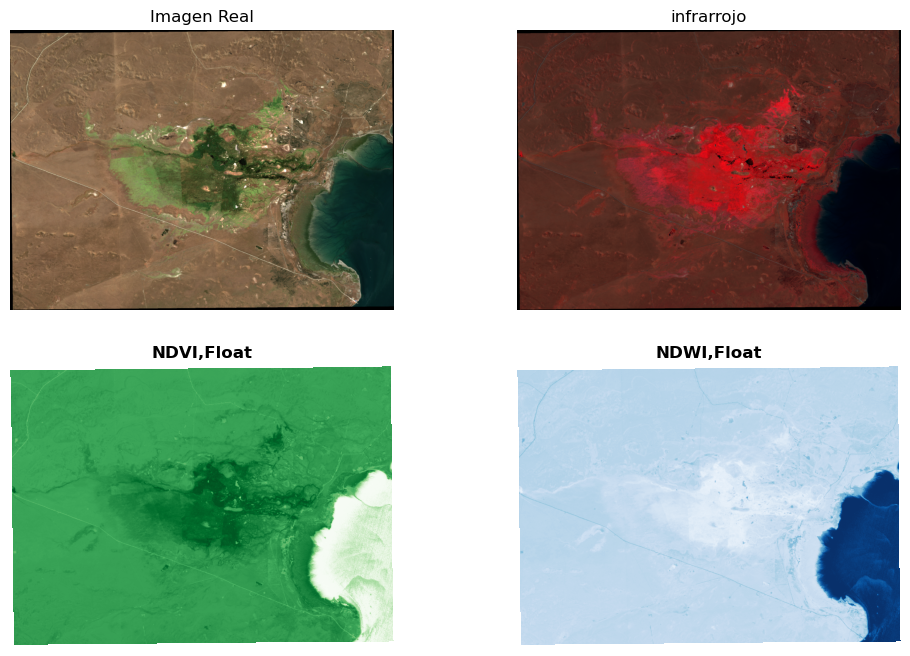

In [9]:
plt.figure(figsize=(12,8))
plt.subplot(221)
rgb= np.dstack((sentinel2.read(4),sentinel2.read(3),sentinel2.read(2)))
plt.imshow(rgb/2000)
plt.axis("off")
plt.title("Imagen Real");

plt.subplot(222)
red= np.dstack((sentinel2.read(8),sentinel2.read(4),sentinel2.read(3)))
plt.imshow(red/6200)
plt.axis("off")
plt.title("infrarrojo");

band3_float = sentinel2.read(3).astype(float)
band4_float = sentinel2.read(4).astype(float)
band8_float = sentinel2.read(8).astype(float)

plt.subplot(223)
ndvi_float = (band8_float - band4_float) / (band8_float + band4_float)
plt.imshow(ndvi_float,cmap= 'Greens',vmax=1,vmin=-1)
plt.axis("off")
plt.title("NDVI,Float",fontweight="bold");


plt.subplot(224)
ndwi_float = (band3_float - band8_float) / (band3_float + band8_float)
plt.imshow(ndwi_float,cmap= 'Blues',vmax=1,vmin=-1)
plt.axis("off")
plt.title("NDWI,Float",fontweight="bold");

plt.savefig(r"C:\Users\bruta\Documents\maletin\UACH\septimo semestre\SIG\practico 5\plot_mapas.jpg")

### Indicaciones práctico 5b

<strong>B.</strong> Trabajaremos con datos de temperatura medidos en un refrigerador con sensores de bajo
costo Arduino y con sensores comerciales Hobo (> 5 veces más caros). 

1. Descargar datos arduino_hobo_temp.csv desde el siguiente link
https://drive.google.com/open?id=1nXnZn23Sn5eA13HuYhu2NHfABZJ60gta
2. Explorar las bases de datos para obtener estadística descriptiva y la correlación entre las
columnas
3. Generar figura con tres gráficos. El primero mostrando la temperatura de los cuatro
sensores con líneas, el segundo mostrando un histograma con la frecuencia de temperaturas
de un sensor a elección, y el tercero un gráfico de caja con los cuatro sensores.

#### *abriendo base de datos con pandas*

In [7]:
data= pd.read_csv(r"C:\Users\bruta\Documents\maletin\UACH\septimo semestre\SIG\practico 5\arduino_hobo_temp.csv")

#### *Graficos*

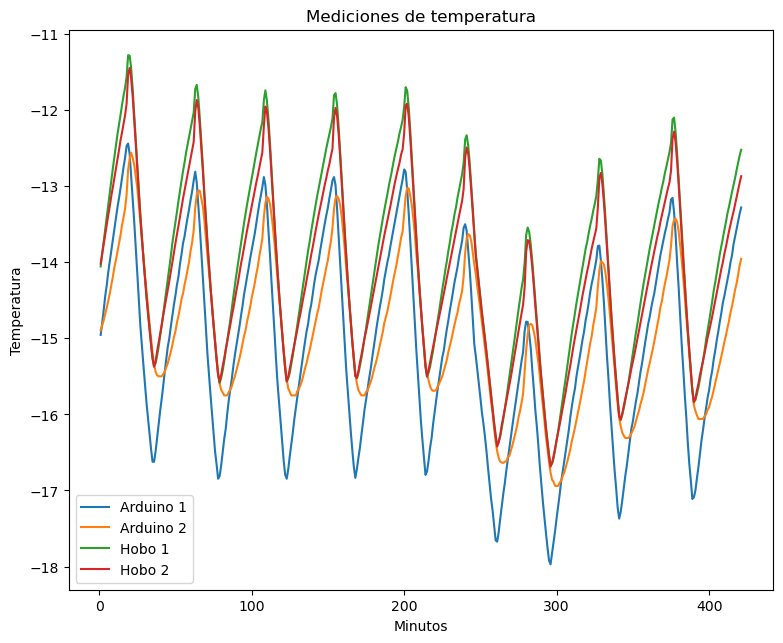

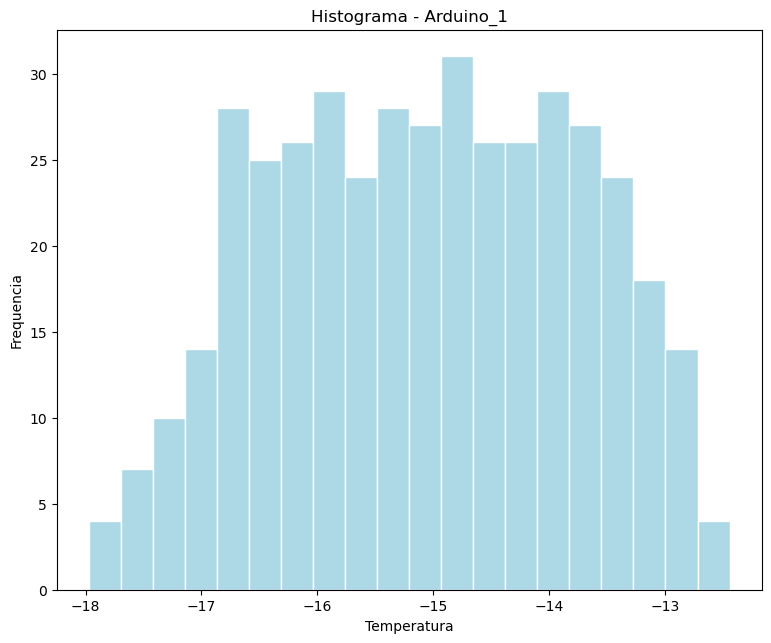

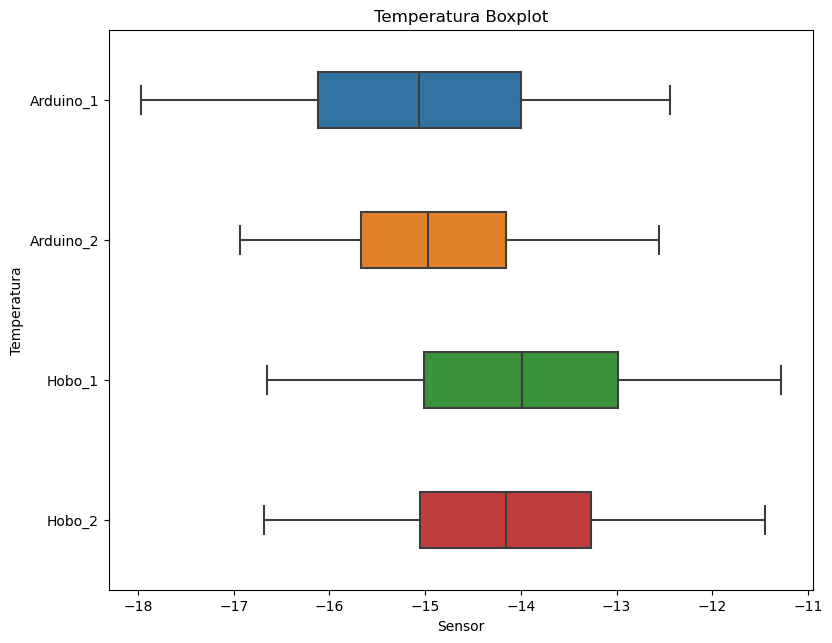

<Figure size 640x480 with 0 Axes>

In [8]:
plt.figure(figsize=(20, 16))
plt.subplot(221)
plt.plot(data['Minuto'], data['Arduino_1'], label='Arduino 1')
plt.plot(data['Minuto'], data['Arduino_2'], label='Arduino 2')
plt.plot(data['Minuto'], data['Hobo_1'], label='Hobo 1')
plt.plot(data['Minuto'], data['Hobo_2'], label='Hobo 2')
plt.xlabel('Minutos')
plt.ylabel('Temperatura')
plt.title('Mediciones de temperatura')
plt.legend()
plt.show()



plt.figure(figsize=(20, 16))
plt.subplot(222)
sensor = 'Arduino_1'  
plt.hist(data[sensor],color="lightblue", edgecolor="white", bins=20)
plt.xlabel('Temperatura')
plt.ylabel('Frequencia')
plt.title('Histograma - {}'.format(sensor))
plt.show()


plt.figure(figsize=(20, 16))
plt.subplot(223)
data_boxplot = data[['Arduino_1', 'Arduino_2', 'Hobo_1', 'Hobo_2']]
box_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
sns.boxplot(data=data_boxplot, palette=box_colors, width=0.4, orient='h')
plt.xlabel('Sensor')
plt.ylabel('Temperatura')
plt.title('Temperatura Boxplot')


plt.show()

plt.savefig (r"C:\Users\bruta\Documents\maletin\UACH\septimo semestre\SIG\practico 5\graficos_practico5.jpg")

### *¿Creen que hay diferencias significativas en las mediciones?*

<strong>R.-</strong>  A través de los gráficos, se puede observar claramente que existen diferencias significativas en las mediciones de temperatura entre los sensores. En las estaciones de monitoreo de Aundino, las mediciones varían considerablemente, lo que indica una disparidad notable en los datos registrados. Por otro lado, en las estaciones de Hobo, ambas mediciones muestran valores similares, lo que sugiere una mayor consistencia en los datos obtenidos.